# **Elements of Computing Final Exam_Part 1:** Luxury Dealership Business Use Case using SQLite with Python


---

# **Project Overview**

As the in-house Marketing and Information Specialist for Elite Motor Dealership, you will analyze historical sales data from the `Luxury_Car_Dlrshp.db` database to drive data-led decision-making at the dealership.

# **Your Task:**

* **Step One -** Upload database to notebook environment. (0 pts)
* **Step Two -** Imports and SQLite database connection. (0 pts)
* **Step Three -** Confirm all tables present in database (0 pts)
* **Step Four -** Complete correctly the (5) SQL queries for total revenue and profit KPIs prompts. (5 pts / each)
* **Step Five -** Complete correctly the (3) SQL queries for customer and sales performance prompts. (5 pts / each)
* **Step Six -** Complete correctly the (2) SQL queries for trade-ins and finance analysis prompts. (5 pts / each)

###**For each prompt, you must:**

- **Task 1:** Execute the correct SQL code.

> **Note** - *"correct"*   SQL code is a query that returns an output that completes all elements of the original prompt.

- **Task 2:** Provide a clear answer to the prompt provided for each query based on your returned output.

- **Task 3:** Offer a strategic suggestion for management at Elite Motor Dealership, identifying how these insights (query returns) can improve business KPIs and or reveal new market opportunities.


# **STEP ONE**

*   Upload the `Luxury_Car_Dlrshp.db` into the "Files" section of this notebook.

    **Note** - This file should appear to the left of this cell once successfully added to "Files".

# **STEP TWO**

*   Import all necessary libraries and packages.
*   Establish the path to the DB stored in Files.

In [124]:
import sqlite3
import pandas as pd

# Set the path to the SQLite database
db_path = "./Luxury_Car_Dlrshp.db"

# Connect to SQLite database
conn = sqlite3.connect(db_path)

# Confirmation
print("Connected to SQLite  database!")

Connected to SQLite  database!



# **STEP THREE**

Confirm the database contains the following four tables:

*   `customers`
*   `financials`
*   `sold_vehicles`
*   `trades`

By running the code block below.

In [125]:
# Returns all tables in database

query_tables = """SELECT name
                  FROM sqlite_schema
                  WHERE type='table'
                  ORDER BY name;"""

# Execute the query using pd.read_sql
df_tables = pd.read_sql(query_tables, conn)

print("These are the four tables in the database")
print(df_tables)

These are the four tables in the database
            name
0      customers
1     financials
2  sold_vehicles
3         trades


# **STEP FOUR**

## **Focus:** Total Revenue and Profit KPIs

To begin your analysis complete the prompts below that calculate the revenue and gross profit for the Elite Motors Dealership historical sales data.

> Remember, the definition for "revenue" is defined in the *Definitions* section of the **Luxury Dealership Business Use Case.pdf** resource included in the final project zip file.


## **`Prompts:`**
1.   Total revenue and total gross profit (total revenue - total cost) from all sold vehicles.
2.   Average gross profit per vehicle sold.
3.   Total number of vehicles sold yearly, for the last 5 years, by year in descending order.
4.   Total sales by vehicle make, excluding `Lexus`, with the 10 highest total sales at the top of the column. Confirm which vehicle make came in third highest and their total sales.
5.   Total number of sales by inventory type: new `N` and used `U`..



---

`Q1 PROMPT:` Total revenue and total gross profit (revenue - cost) from all sold vehicles.

In [126]:
#Q1 QUERY

query_revenue_grossprofit ="""
SELECT SUM(sale_price) AS total_revenue, (SUM(sale_price) - SUM(total_cost)) AS total_gross_profit
FROM financials;
"""

df_revenue_grossprofit = pd.read_sql(query_revenue_grossprofit, conn)

print("Total Revenue and Total Gross Profit")
print(df_revenue_grossprofit)

Total Revenue and Total Gross Profit
   total_revenue  total_gross_profit
0   2.678816e+08        2.516746e+08


`Q1 ANSWER:`

Total Revenue is about $268 million.

Total Gross Profit is about $252 million.


`Q1 ANALYSIS:`
Given how close the total revenue is to the total gross profit, it seems like costs are minimized pretty well already. This leaves the other option left for increasing profit: increasing revenue itself. Perhaps the dealership should explore increasing prices in an attempt to increase revenue.


`Q2 PROMPT:` Average gross profit per vehicle sold.


In [127]:
#Q2 QUERY

query_avg_profit = """
SELECT AVG(sale_price - total_cost) AS avg_profit
FROM financials;
"""

df_avg_profit= pd.read_sql(query_avg_profit, conn)

print("Average Gross Profit: ")
print(df_avg_profit)

Average Gross Profit: 
     avg_profit
0  33228.758602


`Q2 ANSWER:`
Average gross profit per vehicle is about $33,229.

`Q2 ANALYSIS:`
The dealership could prioritize selling cars that provide a gross profit around this $33,229. For example, if there's a Lexus that usually sells for $36,000 but costs the dealership about $3000 total, that is the kind of car they should look to sell more of. Assuming a roughly normal distribution where the average profit is also the most common value for profit, the easiest cars to sell in large quantities would be the ones that the dealership makes a ~$33,000 profit from.


`Q3 PROMPT:` Total number of vehicles sold yearly, for the last 5 years, by year in descending order.


In [128]:
#Q3 QUERY

query_total_sales = """
SELECT strftime('%Y', deal_date) AS year, COUNT(*) AS yearly_sales
FROM financials
GROUP BY year
ORDER BY year DESC
LIMIT 5;
"""

df_total_sales= pd.read_sql(query_total_sales, conn)

print("Total Sales by Year: ")
print(df_total_sales)

Total Sales by Year: 
   year  yearly_sales
0  2017           113
1  2016           585
2  2015           572
3  2014           598
4  2013           592


`Q3 ANSWER:`
The dealership has sold:

113 cars in 2017 (so far - data for 2017 only goes until March)

585 cars in 2016

572 cars in 2015

598 cars in 2014

592 cars in 2013


`Q3 ANALYSIS:`
The dealership should aim to follow recent trends of sales in the high 500s each year. Assuming it is currently the end of March in 2017, i.e. when this database ends, the dealership is on track to fall short of this goal for this year (113*4 = 452 cars by the end of the year). The dealership should push additional advertising to try and attract more customers for the rest of the year.


`Q4 PROMPT:` Total sales by vehicle make, excluding `Lexus`, with the 10 highest total sales at the top of the column. Confirm which vehicle make came in third highest and their total sales.


In [129]:
#Q4 QUERY

query_make_sales = """
SELECT COUNT(*) AS total_sales, vehicle_make
FROM sold_vehicles
WHERE vehicle_make NOT IN ('lexus')
GROUP BY vehicle_make
ORDER BY total_sales DESC
LIMIT 10;
"""

df_make_sales= pd.read_sql(query_make_sales, conn)

print("Total Sales by Make: ")
print(df_make_sales)

Total Sales by Make: 
   total_sales   vehicle_make
0          210         toyota
1           96          honda
2           87  mercedes-benz
3           84           ford
4           78      chevrolet
5           76            bmw
6           73       cadillac
7           71           jeep
8           63         nissan
9           60       chrysler


`Q4 ANSWER:` Mercedes-Benz came in third place, with 87 total sales.

`Q4 ANALYSIS:`
After Lexus, the dealership seems to have the most success selling models from Toyota. They should invest in more Toyota cars to see if that brings in more customers.


`Q5 PROMPT:` Total number of sales by inventory type: new `N` and used `U`.


In [130]:
#Q5 QUERY

query_new_used = """ 
SELECT COUNT(*) AS total_sales, inventory_type
FROM sold_vehicles
GROUP BY inventory_type
ORDER BY total_sales DESC;
"""

df_new_used= pd.read_sql(query_new_used, conn)

print("Total Sales by Inventory Type: ")
print(df_new_used)

Total Sales by Inventory Type: 
   total_sales inventory_type
0         3998              N
1         3576              U


`Q5 ANSWER:`
The dealership has sold 3998 new vehicles and 3576 used ones.

`Q5 ANALYSIS:`
Since the dealership sells more newer models, they should invest more in those newer cars rather than used ones.




---


# **Customer and Sales Performance:**

To continue your analysis complete these prompts below to identify top customers and sales performance by vehicle category.

## **`Prompts:`**

6.   Total vehicles sold for the top 5 customer cities in descending order by total sales. State which `city` is number 1 in total sales.
7.   Top ten postal codes with the highest overall sales as `total_sales` in descending order. The Elite Motors Dealership resides in the 46545 postal code. State the total sales for this postal code.
8.   State the most frequent and least frequent contract term types and their total count.

> **Note**, the observation of `1` in column `contract_term` means the customer paid for the vehicle with cash (1 time) and not through a loan.



`Q6 PROMPT:` Total vehicles sold for the top 5 customer cities in descending order by total sales. State which `city` is number 1 in total sales.


In [131]:
#Q6 QUERY

query_top_customers = """
SELECT COUNT(*) AS total_sales, city
FROM customers
GROUP BY city
ORDER BY total_sales DESC
LIMIT 5;
"""

df_top_customers= pd.read_sql(query_top_customers, conn)

print("Total Sales by City: ")
print(df_top_customers)

Total Sales by City: 
   total_sales          city
0         1512    South Bend
1          946       Granger
2          553       Elkhart
3          516     Mishawaka
4          251  Saint Joseph


`Q6 ANSWER:`
South Bend is the number 1 city in total sales, with 1512.

`Q6 ANALYSIS:`
The dealership should target its advertising towards South Bend and its surrounding area, as this is where they are able to attract the most customers.

`Q7 PROMPT:` Top ten postal codes with the highest overall sales as `total_sales` in descending order. The Elite Motors Dealership resides in the 46545 postal code. State the total sales for this postal code.


In [132]:
#Q7 QUERY

query_postalcodes = """
SELECT COUNT(*) AS total_sales, postal_code
FROM customers
GROUP BY postal_code
ORDER BY total_sales DESC
LIMIT 10;
"""

df_postalcodes= pd.read_sql(query_postalcodes, conn)

print("Total Sales by Postal Code: ")
print(df_postalcodes)

Total Sales by Postal Code: 
   total_sales postal_code
0          945       46530
1          568       46628
2          331       46514
3          324       46614
4          298       46545
5          253       49085
6          221       49120
7          215       46544
8          186       46637
9          160       46526


`Q7 ANSWER:`
The 46545 postal code has 298 total sales.

`Q7 ANALYSIS:`
By far the most popular postal code is 46530, which is Granger, Indiana. The dealership could invest more advertising into Granger to see if they can increase sales from this area even more. Conversely, this can also mean they attract plenty of customers from Granger already, and that other areas are an untapped market. Perhaps they can invest more into bringing customers from 46628, which is currently in second for total sales, to see if they can bring their sales numbers closer to that of 46530 and test if this theory is true.


`Q8 PROMPT:` Total sales as `term_total` by contract term type. State the most frequent and least frequent contract term types and their total count.

> Note, the observation of 1 in column `contract_term` means the customer paid for the vehicle with cash (1 time) and not through a loan.




In [133]:
#Q8 QUERY

query_term_total = """
SELECT COUNT(*) AS term_total, contract_term
FROM financials
GROUP BY contract_term
ORDER BY term_total DESC;
"""

df_term_total= pd.read_sql(query_term_total, conn)

print("Total Sales by Contract Term: ")
print(df_term_total)


Total Sales by Contract Term: 
    term_total  contract_term
0         4497              1
1         1297             60
2          792             36
3          615             48
4          114             72
5           72             24
6           37             66
7           31             39
8           21             42
9           17             75
10          16             51
11          15             63
12          12             27
13           9             84
14           8             77
15           7             54
16           6             33
17           3             45
18           3             30
19           2             69


`Q8 ANSWER:`

The most frequent contract term type is 1, with 4497 total sales.

The least frequent contract term type is 69, with 2 total sales.

`Q8 ANALYSIS:`
Seeing that the majority of customers (4497 out of 7574) pay using a one-time payment instead of through a loan, the dealership should promote this kind of deal the most to attract the large customer base that will sign this one-payment contract.

# **Trade-ins and Finance Analysis:**

To finalize your analysis complete these prompts below to identify the financial impact of trades on the overall gross profit for the dealership.

## **`Prompts:`**

9.   Total number of trade-in vehicles.

> **Note -** `Not Applicable` in column `trade_vin` means there was no vehicle traded-in at the time of the sale.

10.  Average profitability of sales transactions with a trade-in versus without a trade-in vehicle.

`Q9 PROMPT:` Total number of trade-in vehicles.

> **Note -** `Not Applicable` in column `trade_vin` means there was no vehicle traded-in at the time of the sale.






In [134]:
#Q9 QUERY

query_trade_count = """
SELECT COUNT(*) AS trade_in_total
FROM trades
WHERE trade_vin NOT IN ("Not Applicable")
"""

df_trade_count = pd.read_sql(query_trade_count, conn)

print("Total Trade-Ins: ")
print(df_trade_count)

Total Trade-Ins: 
   trade_in_total
0            2965


`Q9 ANSWER:`
There are 2965 total trade-in vehicles.

`Q9 ANALYSIS:`
Since trade-ins make up the minority of transactions for the dealership (2965 out of 7574), perhaps the dealership does not promote trade-in deals enough. There may be a hidden market for customers looking to trade in their current vehicles that is worth exploring.


`Q10 PROMPT:` Average profitability of sales transactions with a trade-in versus without a trade-in vehicle.

In [135]:
#Q10 QUERY

query_profit = """
SELECT AVG(f.sale_price - f.total_cost) AS avg_profit,   
CASE
    WHEN t.trade_vin NOT IN ('Not Applicable') THEN 'With Trade-In'
    ELSE 'Not Trade-In'
END AS trade_in_status
FROM financials as f
JOIN sold_vehicles as sv ON sv.deal_vin = f.deal_vin
JOIN trades AS t ON t.trade_number = sv.deal_number
GROUP BY trade_in_status;
"""


df_profit = pd.read_sql(query_profit, conn)

print("Average Profitability based on Trade-In Status: ")
print(df_profit)

Average Profitability based on Trade-In Status: 
     avg_profit trade_in_status
0  30832.614086    Not Trade-In
1  36025.881161   With Trade-In


***Note: these profit values are slightly skewed due to rows with repeated deal_vin values being doubled when joining tables. After much trial and error and upon further research, it seems that properly disposing of these duplicates requires functions not covered in this course (like ROW_NUMBER() and PARTITION BY), so I decided to leave the duplicates be. However, the results should be pretty close to the actual averages and the general trends can still be observed.***

`Q10 ANSWER:`

For non-trade-in vehicles, the average profit is roughly $30,833.

For trade-in vehicles, the average profit is roughly $36,026.

`Q10 ANALYSIS:`
Since trade-in deals are more profitable for the dealership, they should encourage customers to pursue trade-ins more.


# **STEP FIVE**

## **Focus:** Advanced Visualizations

Let's start by converting each table into respective pandas dataframes.

In [136]:
# create a dataframe for financials
query_financials = """
SELECT *
FROM financials
""" 
df_financials = pd.read_sql(query_financials, conn)

# confirm that the dataframe was properly created
print(df_financials)

               deal_vin            deal_date  sale_price  total_cost  \
0     JNKBV61F97M823138  2009-10-17 00:00:00    26500.00     1876.14   
1     JTHCL46F895000723  2009-10-17 00:00:00    64811.00     6496.11   
2     1FBSS3BL1EDA99461  2015-10-20 00:00:00    27250.00     1305.00   
3     JTJBT20X660123008  2009-10-16 00:00:00    34150.00     2940.80   
4     JTHBJ46G272128707  2009-10-15 00:00:00    24767.29     3430.34   
...                 ...                  ...         ...         ...   
7569  JTHBJ46G172013774  2006-05-24 00:00:00    41000.00     3692.35   
7570  JTJBT20XX60112867  2006-05-26 00:00:00    52125.00     3837.00   
7571  JTHCH96S160014287  2006-05-19 00:00:00    49000.00     4290.80   
7572  JTHBJ46G172007618  2006-05-18 00:00:00    36470.00     3440.75   
7573  JTJBT20X660113160  2006-05-17 00:00:00    50984.00     3467.25   

      vehicle_recon  vehicle_pack  backend_trans  frontend_trans  \
0      2.273737e-13             0        -458.71         2334.85   

In [137]:
# create a dataframe for customers
query_customers = """
SELECT *
FROM customers
""" 
df_customers = pd.read_sql(query_customers, conn)

# confirm that the dataframe was properly created
print(df_customers)

           purchase_vin           city state postal_code
0     JNKBV61F97M823138     Middlebury    IN       46540
1     JTHCL46F895000723  Michigan City    IN       46360
2     1FBSS3BL1EDA99461   Francesville    IN       47946
3     JTJBT20X660123008  Overland Park    KS       66224
4     JTHBJ46G272128707     Valparaiso    IN       46385
...                 ...            ...   ...         ...
7569  JTHBJ46G172013774        Bristol    IN       46507
7570  JTJBT20XX60112867     Valparaiso    IN       46383
7571  JTHCH96S160014287   Stevensville    MI       49127
7572  JTHBJ46G172007618  Ft Lauderdale    FL       33316
7573  JTJBT20X660113160         Goshen    IN       46526

[7574 rows x 4 columns]


In [138]:
# create a dataframe for sold vehicles
query_sv = """
SELECT *
FROM sold_vehicles
""" 
df_sv = pd.read_sql(query_sv, conn)

# confirm that the dataframe was properly created
print(df_sv)

      deal_number           deal_vin inventory_type vehicle_make  \
0         2007906  JNKBV61F97M823138              U     infiniti   
1         2007905  JTHCL46F895000723              N        lexus   
2         2007904  1FBSS3BL1EDA99461              U         ford   
3         2007902  JTJBT20X660123008              U        lexus   
4         2007896  JTHBJ46G272128707              U        lexus   
...           ...                ...            ...          ...   
7569          204  JTHBJ46G172013774              N        lexus   
7570          199  JTJBT20XX60112867              N        lexus   
7571          149  JTHCH96S160014287              N        lexus   
7572          136  JTHBJ46G172007618              N        lexus   
7573          120  JTJBT20X660113160              N        lexus   

         vehicle_model  vehicle_model_year  
0                 G35x                2007  
1               LS 460                2009  
2     E-350 Super Duty                2014  
3  

In [139]:
# create a dataframe for trade-ins
query_trade = """
SELECT *
FROM trades
""" 
df_trade = pd.read_sql(query_trade, conn)

# confirm that the dataframe was properly created
print(df_trade)

      trade_number          trade_vin      trade_year      trade_make  \
0          2007906  JNKCV51E56M505389            2006        Infiniti   
1          2007905     Not Applicable  Not Applicable  Not Applicable   
2          2007904     Not Applicable  Not Applicable  Not Applicable   
3          2007902  1GKEK63U94J102502            2004             GMC   
4          2007896     Not Applicable  Not Applicable  Not Applicable   
...            ...                ...             ...             ...   
7569           204  JTHBF30GX20017542            2002           Lexus   
7570           199  JTJHT00W753553701            2005           Lexus   
7571           149  JT3HN86R5Y0273878            2000          Toyota   
7572           136     Not Applicable  Not Applicable  Not Applicable   
7573           120  5UXFA53502LP49778            2002             BMW   

         trade_model  
0                G35  
1     Not Applicable  
2     Not Applicable  
3              Yukon  
4     No

Let's visualize some more complex comparisons using multiple tables. Although we ran into trouble with duplicates before with SQL, we have more tools in our Pandas toolbox that makes handling them easier. Even better, in this specific case, it seems that the database is already ordered by descending deal_number. We can confirm this by seeing if the ordering of deal_vins match up.

In [140]:
print(df_financials['deal_vin'])

0       JNKBV61F97M823138
1       JTHCL46F895000723
2       1FBSS3BL1EDA99461
3       JTJBT20X660123008
4       JTHBJ46G272128707
              ...        
7569    JTHBJ46G172013774
7570    JTJBT20XX60112867
7571    JTHCH96S160014287
7572    JTHBJ46G172007618
7573    JTJBT20X660113160
Name: deal_vin, Length: 7574, dtype: object


In [141]:
print(df_sv['deal_vin'])

0       JNKBV61F97M823138
1       JTHCL46F895000723
2       1FBSS3BL1EDA99461
3       JTJBT20X660123008
4       JTHBJ46G272128707
              ...        
7569    JTHBJ46G172013774
7570    JTJBT20XX60112867
7571    JTHCH96S160014287
7572    JTHBJ46G172007618
7573    JTJBT20X660113160
Name: deal_vin, Length: 7574, dtype: object


This is great news! This means that the rows for each of our tables are indexed the same. Therefore, we can combine tables using these indices as our 'join keys' rather than a column like deal_vin which gives us duplicate complications. Let's make a new dataframe that does just that.

In [142]:
# Join financials and sold_vehicles over their common indexing
df_f_and_sv = pd.merge(df_financials,df_sv,left_index=True,right_index=True)
display(df_f_and_sv)

,deal_vin_x,deal_date,sale_price,total_cost,vehicle_recon,vehicle_pack,backend_trans,frontend_trans,contract_term,deal_number,deal_vin_y,inventory_type,vehicle_make,vehicle_model,vehicle_model_year
0,JNKBV61F97M823138,2009-10-17 00:00:00,26500.00,1876.14,2.273737e-13,0,-458.71,2334.85,1,2007906,JNKBV61F97M823138,U,infiniti,G35x,2007
1,JTHCL46F895000723,2009-10-17 00:00:00,64811.00,6496.11,0.000000e+00,-200,-901.26,7597.37,1,2007905,JTHCL46F895000723,N,lexus,LS 460,2009
2,1FBSS3BL1EDA99461,2015-10-20 00:00:00,27250.00,1305.00,0.000000e+00,0,0.00,1305.00,1,2007904,1FBSS3BL1EDA99461,U,ford,E-350 Super Duty,2014
3,JTJBT20X660123008,2009-10-16 00:00:00,34150.00,2940.80,0.000000e+00,0,-813.62,3754.42,1,2007902,JTJBT20X660123008,U,lexus,GX 470,2006
4,JTHBJ46G272128707,2009-10-15 00:00:00,24767.29,3430.34,0.000000e+00,0,-976.78,4407.12,1,2007896,JTHBJ46G272128707,U,lexus,ES 350,2007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7569,JTHBJ46G172013774,2006-05-24 00:00:00,41000.00,3692.35,0.000000e+00,-200,-598.65,4491.00,1,204,JTHBJ46G172013774,N,lexus,ES 350,2007
7570,JTJBT20XX60112867,2006-05-26 00:00:00,52125.00,3837.00,0.000000e+00,-200,-495.00,4532.00,36,199,JTJBT20XX60112867,N,lexus,GX 470,2006
7571,JTHCH96S160014287,2006-05-19 00:00:00,49000.00,4290.80,0.000000e+00,-200,-545.08,5035.88,1,149,JTHCH96S160014287,N,lexus,GS 300,2006
7572,JTHBJ46G172007618,2006-05-18 00:00:00,36470.00,3440.75,0.000000e+00,-200,-437.25,4078.00,1,136,JTHBJ46G172007618,N,lexus,ES 350,2007


Lastly, our main goal is to maximize profit. Let's create a column that shows the gross profit (revenue - total cost) of each transaction.

In [143]:
# create a column 
profit_col = df_financials['sale_price'] - df_financials['total_cost']

df_f_and_sv.insert(4,'gross_profit',profit_col)

# show the first few rows to confirm that the column was correctly added
df_f_and_sv.head()

,deal_vin_x,deal_date,sale_price,total_cost,gross_profit,vehicle_recon,vehicle_pack,backend_trans,frontend_trans,contract_term,deal_number,deal_vin_y,inventory_type,vehicle_make,vehicle_model,vehicle_model_year
0,JNKBV61F97M823138,2009-10-17 00:00:00,26500.00,1876.14,24623.86,2.273737e-13,0,-458.71,2334.85,1,2007906,JNKBV61F97M823138,U,infiniti,G35x,2007
1,JTHCL46F895000723,2009-10-17 00:00:00,64811.00,6496.11,58314.89,0.000000e+00,-200,-901.26,7597.37,1,2007905,JTHCL46F895000723,N,lexus,LS 460,2009
2,1FBSS3BL1EDA99461,2015-10-20 00:00:00,27250.00,1305.00,25945.00,0.000000e+00,0,0.00,1305.00,1,2007904,1FBSS3BL1EDA99461,U,ford,E-350 Super Duty,2014
3,JTJBT20X660123008,2009-10-16 00:00:00,34150.00,2940.80,31209.20,0.000000e+00,0,-813.62,3754.42,1,2007902,JTJBT20X660123008,U,lexus,GX 470,2006
4,JTHBJ46G272128707,2009-10-15 00:00:00,24767.29,3430.34,21336.95,0.000000e+00,0,-976.78,4407.12,1,2007896,JTHBJ46G272128707,U,lexus,ES 350,2007


Now, we can finally get to some visuals. I'd like to see how profit distributions compare across brands. Before, in SQL, we saw the top Non-Lexus brands in terms of sales numbers: Toyota, Honda, and Mercedes-Benz. Now let's see how profits for those brands compare to each other and to Lexus.

In [144]:
# Limit the dataframe to the top 4 selling brands
df_top_brands = df_f_and_sv[(df_f_and_sv['vehicle_make'] == 'lexus') 
                            | (df_f_and_sv['vehicle_make'] == 'toyota')
                            | (df_f_and_sv['vehicle_make'] == 'honda')
                            | (df_f_and_sv['vehicle_make'] == 'mercedes-benz')]

We can use a violin plot to compare the distributions of gross profit for each of these brands.

Text(0.5, 1.0, 'Profit Distributions for Top Selling Brands')

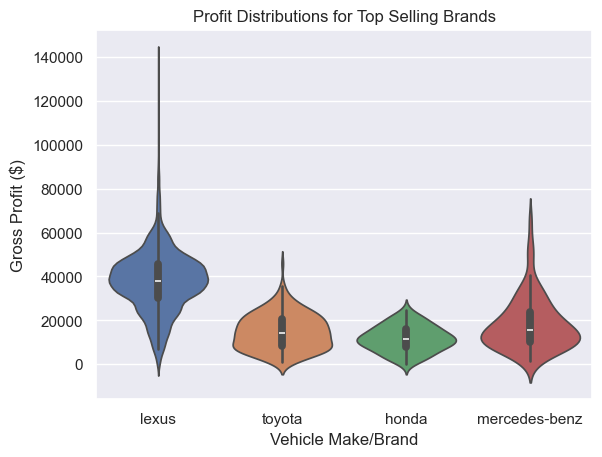

In [145]:
# Use a violin plot to plot profit distributions of different brands
import seaborn as sns
import matplotlib.pyplot as plt

# Plot with style and hue parameters
sns.set_theme(style="darkgrid")
sns.violinplot(df_top_brands, x='vehicle_make', y='gross_profit',hue='vehicle_make') 

# Add axes labels and a title
plt.xlabel('Vehicle Make/Brand')
plt.ylabel('Gross Profit ($)')
plt.title('Profit Distributions for Top Selling Brands')

Here we have a couple takeaways:

1. Lexus is easily the most profitable brand, with a median gross profit of around $40,000 per vehicle. It makes sense to stick to selling a lot of Lexuses (Lexi? Whatever the plural of Lexus is).
2. The next three have pretty similar distributions for gross profit, all centered around $12k to $15k. Although it's marginal, Mercedes-Benz seems to have more success at higher profit values than the other two. This may point to a potential market opportunity with Mercedes. The dealership could look into investing into more Mercedes models and see if the customers follow.

Next, let's gain more insight on the customer base. In the SQL section before, we discovered that the majority of customers tend to make one-time payments rather than taking out a loan. If we want to advertise this deal more, we should also find the places where it is most popular so we can target ads to those areas.

First, let's create a dataframe connecting *financials* with *customers* and limit it to only rows where contract_term is 1 (for one-time payments).

In [146]:
# create a dataframe of financials and customers who signed one-time-payment contracts
df_fc = pd.merge(df_financials, df_customers, left_index=True, right_index=True)
df_fc = df_fc[df_fc['contract_term'] == 1]

Next, we want to group our data by cities and postal codes and find the count of customers with 1 time purchases for each one. Since we want to find the areas where this deal is most popular, we'll only look at the areas whose postal codes have more than 100 of these purchases recorded.

In [147]:
# create a dataframe containing the counts of one-time-purchases by city and postal code
df_one_counts = df_fc.groupby(['city','postal_code']).size().reset_index(name='one_time_count')
df_one_counts = df_one_counts[df_one_counts['one_time_count'] > 100]
df_one_counts.head()

,city,postal_code,one_time_count
160,Elkhart,46514,189
226,Granger,46530,507
391,Mishawaka,46544,123
392,Mishawaka,46545,143
430,Niles,49120,131


We can plot this hierarchical kind of data using a sunburst plot.

In [148]:
import plotly.express as px

# Make a sunburst plot for one-time purchase customers by location
fig = px.sunburst(df_one_counts, 
                  path=['city','postal_code'], 
                  values='one_time_count',
                  width = 750,
                  height = 750,
                  title="Number of Customers Making One Time Purchases by Location")

fig.show()

Here's the key takeaway: South Bend and Granger, specifically postal codes 46628 and 46530, contain the most customers willing to make one-time-purchases. As a result, to attract more customers, the dealership should specifically advertise this one-time-payment deal to these two zip codes.

Lastly, let's take one last look at trade-ins. I think it would be interesting to see if the value of trade-ins and non-trade-ins (in terms of gross profit) has changed over time and if that change is different between the two. That way, we can better evaluate whether or not the dealership should currently invest in more trade-in deals or non-trade-in ones.

In [149]:
# create a dataframe connecting trades to our financial/sold vehichles table
df_fin_to_trade = pd.merge(df_f_and_sv,df_trade,left_index=True,right_index=True)

# create a boolean mask that asks whether the vehicle is a trade in or not
ask_trade = df_fin_to_trade['trade_vin'] != 'Not Applicable'

# add this new column to the data frame
df_fin_to_trade.insert(17,'trade_status',ask_trade)


So we don't have a million datapoints, we can look at the average gross profit each year to see its change over time for both trade-ins and non-trade-ins.

In [150]:
# convert the deal_date variable to just its year
year = pd.DatetimeIndex(df_fin_to_trade['deal_date']).year

# use only the gross_profit, trade_status, and new year column
df_condensed = df_fin_to_trade[['gross_profit','trade_status']].copy()
df_condensed.insert(2,'year',year)

# create a new dataframe that takes the average gross profit per year
df_by_year= df_condensed.groupby(['year','trade_status'])['gross_profit'].mean().reset_index(name='avg_profit')
df_by_year.head()


,year,trade_status,avg_profit
0,2004,False,28706.022403
1,2004,True,37575.073558
2,2005,False,30028.467891
3,2005,True,37426.921947
4,2006,False,29673.300026


Now, we can see the general trend over time using a regression plot. I decided to use a third-degree polynomial regression, as I believe it gives us a pretty close model based on the behavior of our given datapoints.

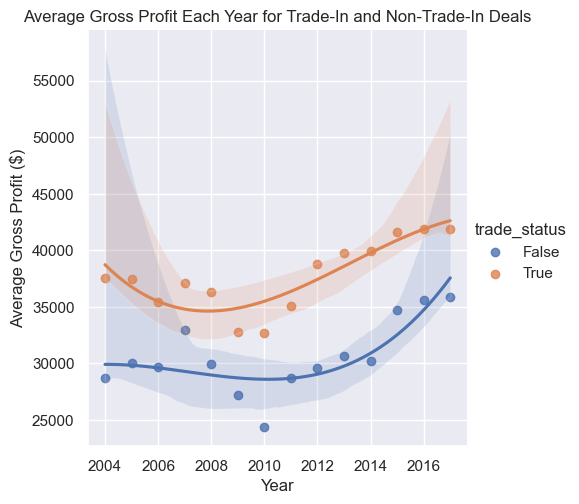

In [151]:
# Make a regression plot for the year-by-year avg profits for both trade-ins and non-trade-ins
reg = sns.lmplot(data=df_by_year,
            x='year',
            y = 'avg_profit',
            hue = 'trade_status',
            order = 3)

plt.xlabel('Year')
plt.ylabel('Average Gross Profit ($)')
plt.title('Average Gross Profit Each Year for Trade-In and Non-Trade-In Deals')

plt.show()

The main takeaway here is that it seems like gross profit has been increasing in recent years for both trade-in and non-trade-in deals. Since trade-in deals provide more profit than non-trade-in ones and since these profits are both trending upward, it's safe to say the dealership should prioritize trade-in deals if they'd like to maximize profit.

In [152]:
# Close the connection
conn.close()